# Constrained Expected Improvement with Probability of Feasibility

This section demonstrates the implementation of constrained BO with the acquisition function being the product of EI and the probability of feasibility (PF). In this formulation, the conventional EI acquisitoin function is multiplied by the PF value for each constraint function of the problem and the product is maximized. The auxilliary optimization problem formulation can be written as

$$
    \begin{align*}
        \max_{x \in \Omega} \quad & EI(x) \times \prod_{i=1}^{m} PF_i(x)
    \end{align*}
$$

where $PF_i(x)$ is the PF for constraint $g_i$. It is defined as

$$
    \begin{align*}
        PF_i(x) = P[G_i(x) \leq 0] = \Phi \Bigg( -\frac{\hat{g}_i(x)}{\hat{\sigma}_{g,i}(x)}\Bigg),
    \end{align*}
$$

where $G_i$ is the random variable associated with the surrogate model. The $\hat{g}_i$ and $\hat{\sigma}_{g,i}$ is the mean prediction and the standard deviation from the constraint surrogate model, respectively. $\Phi$ is the cummulative distribution function for the standard normal distribution and $m$ is the total number of constraints. Essentially, the $PF_i$ defines the probability that constraint $g_i$ is less than 0 i.e. the constraint is satisfied. The EI is defined in a [previous section](https://computationaldesignlab.github.io/surrogate-methods/bo/ei.html).

In constrast to the previous formulations for constrained BO, the auxiliary optimization problem in this case only has bound constraints but no other constraints since the other constraints of the optimization problem are accounted for by the PF term in the acquisition function.

Below code imports required packages, defines modified branin function and the constraint function. 

In [8]:
import numpy as np
import torch
from pyDOE3 import lhs
import matplotlib.pyplot as plt
from scipy.stats import norm as normal
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

# Defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float64
}

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

def constraint(x):
    """
        Function for computing constraint function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    g = -x1*x2 + 30
    
    return np.expand_dims(g,-1)

# Bounds
lb = np.array([-5, 0])
ub = np.array([10, 15])

The block of code below defines the pymoo class for solving the auxiliary optimization problem. The problem class computes both EI and PF and then stores the product as the objective function value in the `out` dictionary in the `_evaluate` method of the class. The product is negated since pymoo minimizes the objective function by default. The `differential evolution` class is also defined in the next code block in a manner that is identical to the previous sections. 

In [9]:
class EIPF(Problem):

    def __init__(self, gp_obj, gp_const, lb: np.ndarray, ub: np.ndarray, fbest: float):
        """
            Class for defining auxiliary optimization problem that uses
            expected improvment with probability of feasibility as the acquisition function.
            The mean prediction and standard deviation of the constraint are function 
            are obtained from the surrogate model. 
        """

        # initialize parent class
        super().__init__(n_var=lb.shape[0], n_obj=1, n_constr=0, xl=lb, xu=ub)

        # store variables
        self.gp_obj = gp_obj
        self.gp_const = gp_const
        self.fbest = fbest

    def _evaluate(self, x, out, *args, **kwargs):

        # convert to torch tensor
        x = torch.from_numpy(x).to(self.gp_obj.x_train)

        # get mean prediction and std in prediction
        y_mean, y_std = self.gp_obj.predict(x)

        # get constraint prediction
        g_mean, g_std = self.gp_const.predict(x)

        # numerator of Z
        numerator = self.fbest - y_mean.numpy(force=True)

        # denominator of Z
        denominator = y_std.numpy(force=True)

        # std variable
        z = numerator / denominator

        # compute ei
        ei = numerator * normal.cdf(z) + denominator * normal.pdf(z)
        
        # compute pf
        pf = normal.cdf( - g_mean.numpy(force=True) / g_std.numpy(force=True)) 
        
        # EI * PF
        # Negative sign because we want to maximize
        out["F"] = - (ei * pf)

# optimization algorithm
algorithm = DE(pop_size=15*lb.shape[0], F=0.9, CR=0.8, seed=1)

## BO Loop

The block of code below implements the BO loop for constrained expected improvement with probability of feasibility. The number of initial samples is 4 with the maximum function evaluations set to 30. This means that there will be 26 iterations of the loop. Latin Hypercube sampling is used to generate the initial samples. Gaussian process (GP) models are used to approximate the modified Branin function and the constraint function of the problem. This is because GP models provide both a mean prediction and the uncertainty in the model prediction, which is necessary for calculating EI and PF. 

In [ ]:
# variables
num_init = 4
max_evals = 30
num_evals = 0

# initial training data
x_train = lhs(lb.shape[0], samples=num_init, criterion='cm', iterations=100, seed=1)
x_train = lb + (ub - lb) * x_train
y_train = modified_branin(x_train)
g_train = constraint(x_train)

# increment evals
num_evals += num_init

ybest = np.min(y_train[g_train < 0])
idx_best = np.where(y_train == ybest)[0][0]
fbest = [ybest]
xbest = [x_train[idx_best]]
gbest = [g_train[idx_best]]

print("Current best before loop:")
print("x: {}".format(xbest[-1]))
print("f: {}".format(fbest[-1]))
print("g: {}".format(gbest[-1]))

print("\nEIPF Loop:")

# loop
while num_evals < max_evals:

    print(f"\nIteration: {num_evals-num_init+1}")

    # training the objective function GP model
    gp_obj = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(y_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )
    mll_obj = ExactMarginalLogLikelihood(gp_obj.likelihood, gp_obj) # marginal log likelihood
    optimizer = torch.optim.Adam(gp_obj.parameters(), lr=0.01) # optimizer
    gp_obj.fit(training_iterations=1000, mll=mll_obj, optimizer=optimizer)

    # training the constraint function GP model
    gp_const = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(g_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )
    mll_const = ExactMarginalLogLikelihood(gp_const.likelihood, gp_const) # marginal log likelihood
    optimizer = torch.optim.Adam(gp_const.parameters(), lr=0.01) # optimizer
    gp_const.fit(training_iterations=1000, mll=mll_const, optimizer=optimizer)

    # Find the minimum of surrogate model
    result = minimize(EIPF(gp_obj, gp_const, lb, ub, fbest[-1]), algorithm, verbose=False)

    # Computing true function value at infill point
    y_infill = modified_branin(result.X)
    g_infill = constraint(result.X)

    print("New point (based on EIPF):")
    print("x: {}".format(result.X))
    print("f: {}".format(y_infill.item()))

    # Appending the the new point to the current data set
    x_train = np.vstack(( x_train, result.X.reshape(1,-1) ))
    y_train = np.vstack((y_train, y_infill))
    g_train = np.vstack((g_train, g_infill))

    # increment evals
    num_evals += 1

    # Find current best point
    ybest = np.min(y_train[g_train < 0])
    idx_best = np.where(y_train == ybest)[0][0]
    fbest.append(ybest)
    xbest.append(x_train[idx_best])
    gbest.append(g_train[idx_best])
    
    print("Current best:")
    print("x: {}".format(xbest[-1]))
    print("f: {}".format(fbest[-1]))
    print("g: {}".format(gbest[-1]))

fbest = np.array(fbest)
xbest = np.array(xbest)
gbest = np.array(gbest)

Current best before loop:
x: [8.125 9.375]
f: 108.5539005871506
g: [-46.171875]

EIPF Loop:

Iteration: 1
New point (based on EIPF):
x: [7.29592708 5.12839286]
f: 66.49216716567288
Current best:
x: [7.29592708 5.12839286]
f: 66.49216716567288
g: [-7.41638036]

Iteration: 2
New point (based on EIPF):
x: [-5.00000000e+00  6.49739615e-17]
f: 283.1290960116062
Current best:
x: [7.29592708 5.12839286]
f: 66.49216716567288
g: [-7.41638036]

Iteration: 3
New point (based on EIPF):
x: [ 7.68101461 14.0850641 ]
f: 211.04687282864134
Current best:
x: [7.29592708 5.12839286]
f: 66.49216716567288
g: [-7.41638036]

Iteration: 4
New point (based on EIPF):
x: [10.          6.32842555]
f: 63.001884377989015
Current best:
x: [10.          6.32842555]
f: 63.001884377989015
g: [-33.28425552]

Iteration: 5
New point (based on EIPF):
x: [10.          2.86720759]
f: 51.96156845756788
Current best:
x: [10.          6.32842555]
f: 63.001884377989015
g: [-33.28425552]

Iteration: 6
New point (based on EIPF):
x

/Users/gallifrey/miniconda3/envs/ece60146/lib/python3.12/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


New point (based on EIPF):
x: [10.          3.00518224]
f: 51.9431456163136
Current best:
x: [10.          3.00518224]
f: 51.9431456163136
g: [-0.05182236]

Iteration: 8
New point (based on EIPF):
x: [ 2.6587634 15.       ]
f: 166.53099785319824
Current best:
x: [10.          3.00518224]
f: 51.9431456163136
g: [-0.05182236]

Iteration: 9
New point (based on EIPF):
x: [4.78270339 6.22655282]
f: 58.43633549623163
Current best:
x: [10.          3.00518224]
f: 51.9431456163136
g: [-0.05182236]

Iteration: 10
New point (based on EIPF):
x: [9.6040465  3.14990325]
f: 48.84191604187473
Current best:
x: [9.6040465  3.14990325]
f: 48.84191604187473
g: [-0.25181726]

Iteration: 11
New point (based on EIPF):
x: [9.23436761 3.2525872 ]
f: 47.61472476745784
Current best:
x: [9.23436761 3.2525872 ]
f: 47.61472476745784
g: [-0.03558589]

Iteration: 12
New point (based on EIPF):
x: [3.60416869 8.35251801]
f: 60.523901707801286
Current best:
x: [9.23436761 3.2525872 ]
f: 47.61472476745784
g: [-0.0355858

> __*NOTE*__: The minimum obtained at the end of process is the minimum feasible $y$ observed in the training data and **not** the minimum of the surrogate model.

Below block of code plots the evolution of the best objective function, best design point and constraint values of the sampling process through constrained expected improvement with probability of feasibility.

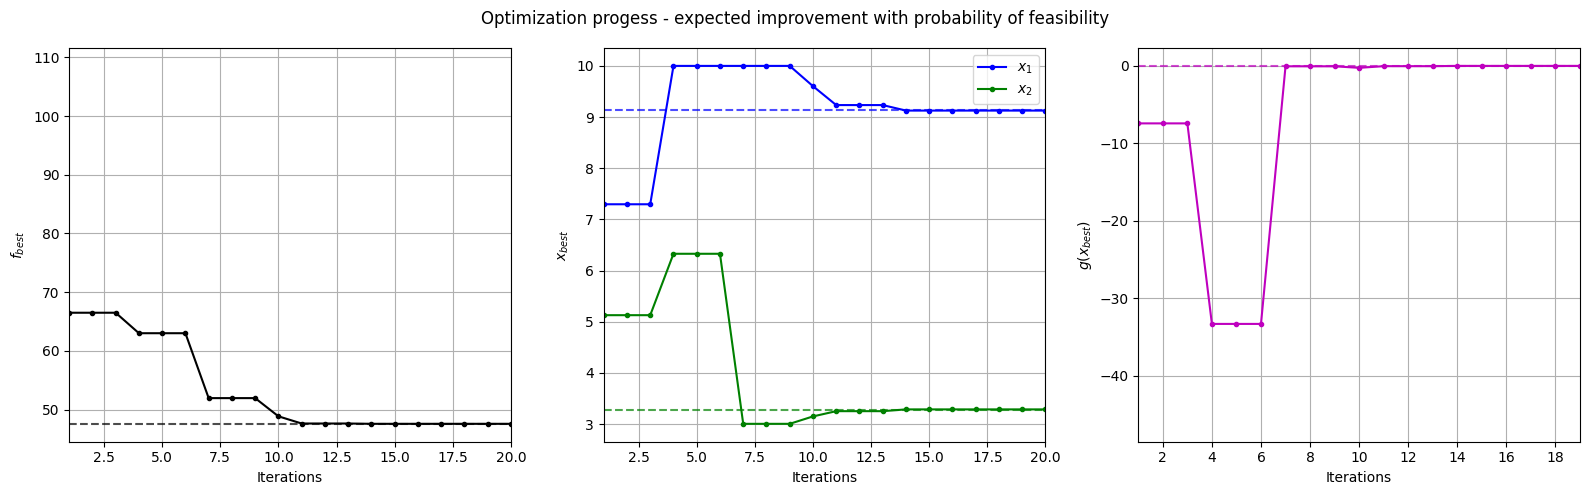

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].plot(fbest, ".k-")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("$f_{best}$")
ax[0].axhline(y=modified_branin(np.array([[9.143, 3.281]])), c="k", linestyle="--", alpha=0.7)
ax[0].set_xlim(left=1, right=fbest.shape[0]-1)
ax[0].grid()

ax[1].plot(xbest[:,0], ".b-", label="$x_1$")
ax[1].plot(xbest[:,1], ".g-", label="$x_2$")
ax[1].axhline(y=9.143, c="b", linestyle="--", alpha=0.7)
ax[1].axhline(y=3.281, c="g", linestyle="--", alpha=0.7)
ax[1].set_xlim(left=1, right=xbest.shape[0]-1)
ax[1].set_ylabel("$x_{best}$")
ax[1].set_xlabel("Iterations")
ax[1].legend()
ax[1].grid()

ax[2].plot(gbest, ".m-")
ax[2].set_xlabel("Iterations")
ax[2].set_ylabel("$g(x_{best})$")
ax[2].axhline(y=0, c="m", linestyle="--", alpha=0.7)
ax[2].set_xlim(left=1, right=g_train[num_init:].shape[0]-1)
ax[2].grid()

_ = plt.suptitle("Optimization progess - expected improvement with probability of feasibility")
plt.tight_layout()

Below block of code plots the infill points along with the contours of the true objective and constraint functions.

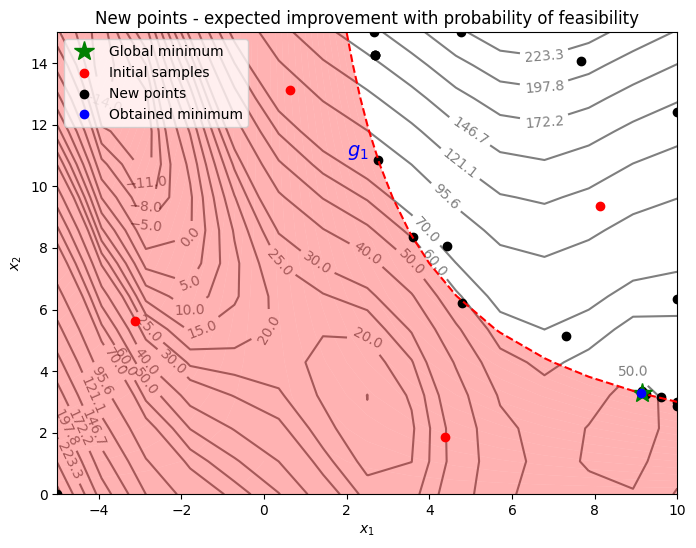

In [14]:
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)
G = constraint(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))

# Contours and global opt
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid', alpha=0.5, zorder=-10)
ax.clabel(CS, inline=1)
ax.plot(9.143, 3.281, 'g*', markersize=15, label="Global minimum")

ax.contour(X1, X2, G, levels=[0], colors='r', linestyles='dashed')
ax.contourf(X1, X2, G, levels=np.linspace(0,G.max()), colors="red", alpha=0.3, antialiased = True)
ax.annotate('$g_1$', xy =(2.0, 11.0), fontsize=14, color='b')

# Pointss
ax.scatter(x_train[0:num_init,0], x_train[0:num_init,1], c="red", label='Initial samples')
ax.scatter(x_train[num_init:,0], x_train[num_init:,1], c="black", label='New points')
ax.plot(xbest[-1][0], xbest[-1][1], 'bo', label="Obtained minimum")

# asthetics
ax.legend(loc="upper left")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
_ = ax.set_title("New points - expected improvement with probability of feasibility")

From the above plot, it can be seen that EI and PF finds the minimum of the modified branin function while balancing exploration and exploitation. The acquisition function adds a few points in the unexplored regions of the feasible space of the optimization problem before finding the global feasible minimum of the problem. 

> __*NOTE*__: Due to randomness in differential evolution, results may vary slightly between runs. So, it is recommended to run the code multiple times to see average behavior.